# Merging `IxIDN_ORDON_benchmark.csv` with its source datasets — **DDA v1**

All logic lives in [`dda_analysis.py`](dda_analysis.py); this notebook only drives it.

Final columns: `ID, d1_disease_label, d2_disease_label, DDA, exist_IxIDN, exist_ORDON, IxIDN_ID, ORDON_ID`,
where `IxIDN_ID` / `ORDON_ID` are 0-based row numbers in the source CSVs (blank when the pair is
absent from that source).

**Join key:** the disease pair `(d1_disease_label, d2_disease_label)`. Pair orientation is *not*
preserved between the benchmark and `IxIDN_df.csv`, so the merge uses an order-insensitive
canonical key — see section 2 for what that is worth.

In [1]:
import dda_analysis as da

da.apply_style()

DDA_FILE = "IxIDN_ORDON_benchmark_DDA_v1.csv"
MERGED_FILE = "IxIDN_ORDON_benchmark_v1_merged.csv"

frames = da.load_sources(DDA_FILE)
da.describe_inputs(frames)

benchmark: 10,336 rows x 5 cols | ['ID', 'd1_disease_label', 'd2_disease_label']
    ixidn:  5,336 rows x 9 cols | ['d1_disease_id', 'd1_disease_label', 'd2_disease_id', 'd2_disease_label', 'drug_labels', 'trial_count_total', 'IxIDN_ID']
    ordon:  5,000 rows x 8 cols | ['d1_disease_id', 'd1_disease_label', 'd2_disease_id', 'd2_disease_label', 'unique_key', 'ORDON_ID']
      dda: 10,336 rows x 4 cols | ['ID', 'd1_disease_label', 'd2_disease_label', 'DDA']

duplicate pair keys within each file (order-insensitive):
  benchmark:    2
      ixidn:    0
      ordon:    0


## 2. Why pair orientation matters

Benchmark rows found under each key definition.

In [2]:
da.orientation_effect(frames)

,"ordered (d1,d2) match",order-insensitive match,gained by ignoring order
IxIDN,2767,5338,2571
ORDON,5002,5002,0


## 3. Merge and flag provenance

In [3]:
merged = da.merge_benchmark(frames)
merged.head()

merged rows: 10,336 (benchmark rows: 10,336)
DDA missing: 0
DDA label mismatches vs benchmark on ID: 0


,ID,d1_disease_label,d2_disease_label,DDA,exist_IxIDN,exist_ORDON,IxIDN_ID,ORDON_ID,key_pair
0,0,Myasthenia gravis,AL amyloidosis,0.2363,True,False,2805,<NA>,AL amyloidosis || Myasthenia gravis
1,1,Burkitt lymphoma,Szary syndrome,0.4545,True,False,536,<NA>,Burkitt lymphoma || Szary syndrome
2,2,MALT lymphoma,"Primary dystonia, DYT4 type",0.1535,False,True,<NA>,3345,"MALT lymphoma || Primary dystonia, DYT4 type"
3,3,Neurotrophic keratopathy,Early-onset generalized limb-onset dystonia,0.1628,False,True,<NA>,4554,Early-onset generalized limb-onset dystonia ||...
4,4,Idiopathic/heritable pulmonary arterial hypert...,Systemic-onset juvenile idiopathic arthritis,0.4341,True,False,4469,<NA>,Idiopathic/heritable pulmonary arterial hypert...


In [4]:
da.merge_summary(merged)

,bucket,rows,pct
0,IxIDN only,5334,51.61
1,ORDON only,4998,48.36
2,both,4,0.04
3,unmatched (neither),0,0.00
4,matched at least one,10336,100.00
5,benchmark total,10336,100.00


### Round-trip coverage

Is every source row reachable from the benchmark, exactly once?

In [5]:
da.coverage_report(merged, frames)
da.write_merged(merged, MERGED_FILE)

IxIDN: 5,336/5,336 unique pairs in benchmark (100.00%) · 5,336/5,336 source rows referenced
ORDON: 5,000/5,000 unique pairs in benchmark (100.00%) · 5,000/5,000 source rows referenced
wrote IxIDN_ORDON_benchmark_v1_merged.csv  (10,336 rows, 8 cols)


PosixPath('/Users/bravandi/GitHub/benchmark-IxIDN-ORDON/claude_science/IxIDN_ORDON_benchmark_v1_merged.csv')

## 4. DDA distribution by source dataset

The few pairs present in *both* sources have no unambiguous label and are excluded from every
comparison below, so the two groups are *IxIDN-only* and *ORDON-only*.

In [6]:
pos, neg = da.split_groups(merged)
da.group_stats(pos, neg)

pairs in both sources (excluded, unlabelable): 4


,n,mean,median,q25,q75,min,max
IxIDN (positive),5334,0.3610,0.3356,0.2512,0.4488,0.0434,0.9574
ORDON (negative),4998,0.2077,0.2018,0.1611,0.2476,0.0060,0.7104


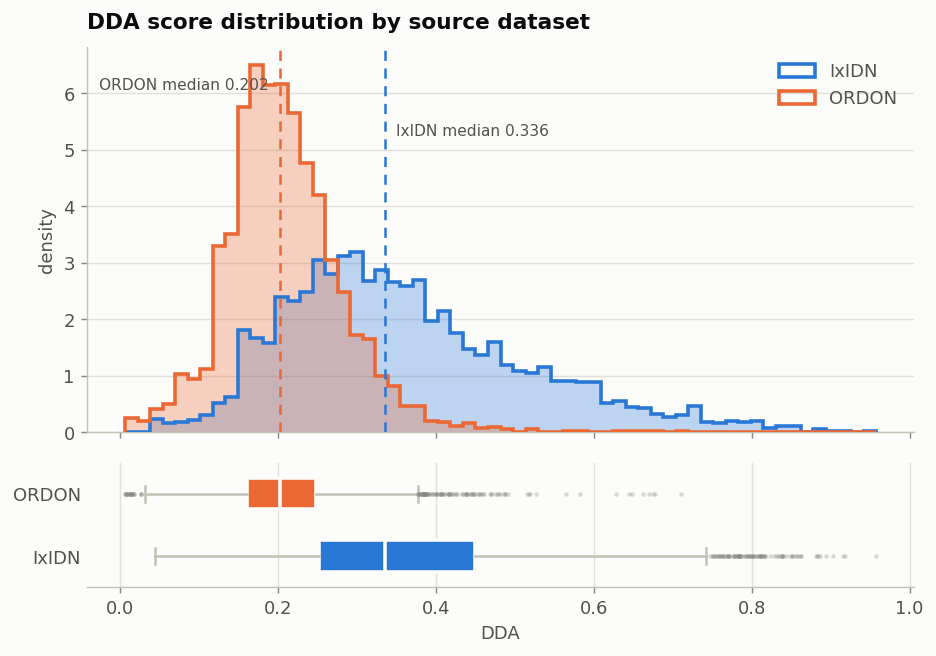

In [7]:
da.plot_distribution(pos, neg)

## 5. ROC — can DDA separate IxIDN from ORDON?

**IxIDN = positive class, ORDON = negative class**, DDA used directly as the score.

*Caveat:* the two classes are *which source file a pair came from*, not validated
positive/negative labels. IxIDN pairs carry clinical-trial evidence while ORDON pairs are
ontology-derived, so this partly measures how well DDA recovers that provenance difference.

In [8]:
roc, wass = da.print_metrics(pos, neg)

AUC                       : 0.8273
  positives (IxIDN)       : 5,334
  negatives (ORDON)       : 4,998
  best threshold (Youden) : DDA >= 0.2745
    TPR (sensitivity)     : 0.683
    FPR                   : 0.154 (specificity 0.846)
Wasserstein distance W1   : 0.1533 DDA units
  normalized by pooled SD : 1.268
  direction               : IxIDN shifted higher (Δ mean +0.1533)
  stochastic dominance    : True (CDF crossings: 0)


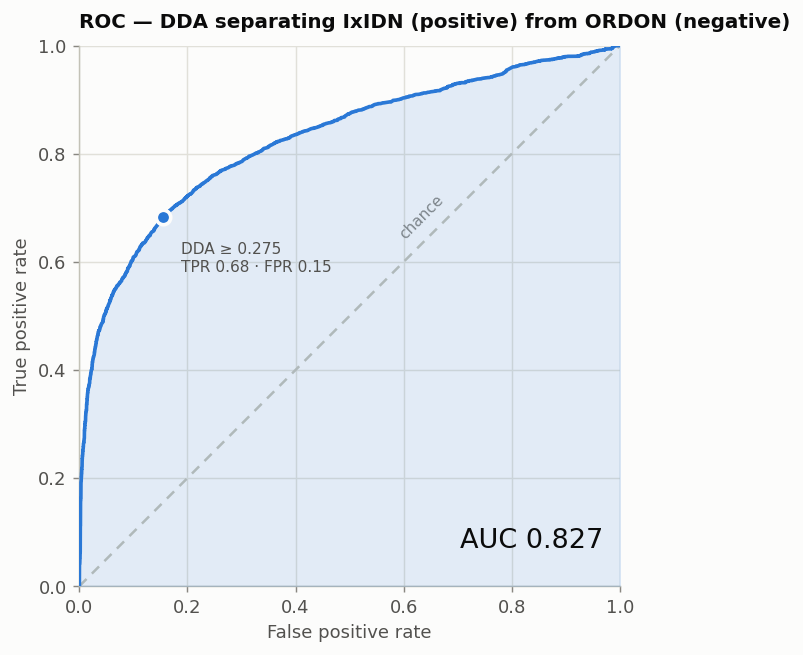

In [9]:
da.plot_roc(pos, neg)

## 6. Wasserstein distance — violin plot

W₁ is in **DDA units**: the mean distance the mass of one distribution must travel to match the
other. It equals the mean difference exactly when the two CDFs never cross, i.e. when one group
stochastically dominates the other across the whole score range (reported above as
`stochastic dominance`).

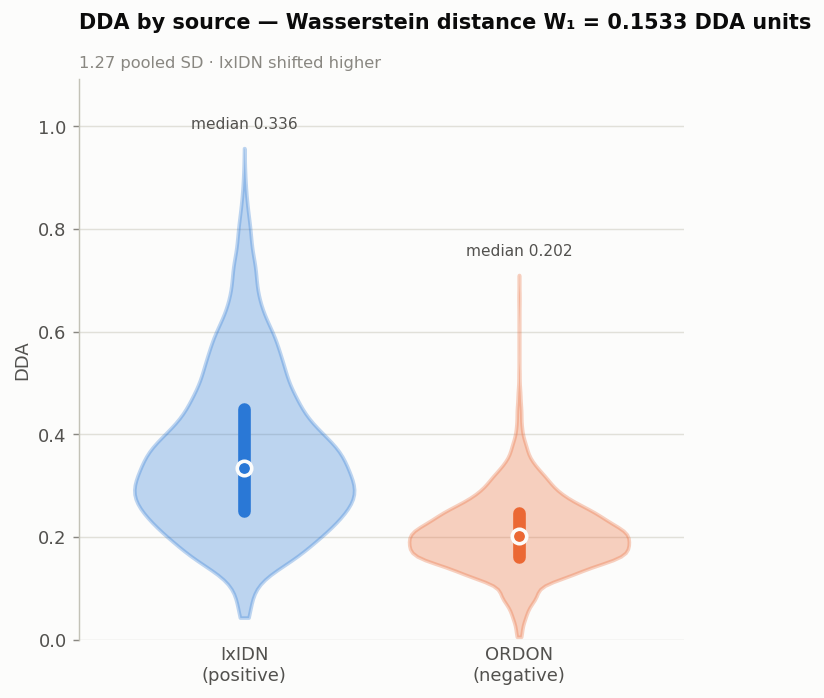

In [10]:
da.plot_violin(pos, neg)